 Download raw OHLCV

In [1]:
import yfinance as yf, pandas as pd
TICKERS = ["AAPL", "MSFT", "GOOGL"]           # add as many as you like
raw = yf.download(" ".join(TICKERS),
                  period="10y",
                  interval="1d",
                  auto_adjust=True, group_by='ticker')
# keep Close price only for simplicity
close = pd.concat({t: raw[t]["Close"] for t in TICKERS}, axis=1).ffill()

[*********************100%***********************]  3 of 3 completed


Transform into sliding windows

In [19]:
import numpy as np
WINDOW = 64          # look-back length
HORIZON = 1         # predict 5 trading days ahead

def make_windows(df, window=WINDOW, horizon=HORIZON):
    X, y = [], []
    for t in range(len(df) - window - horizon):
        X.append(df.iloc[t:t+window].values)               # shape (window, N_tickers)
        future = df.iloc[t+window+horizon-1]               # future Close
        current = df.iloc[t+window-1]
        y.append((future - current) / current)             # % return over horizon
    return np.stack(X), np.stack(y)

X_all, y_all = make_windows(close)

Learn TS2Vec representations (unsupervised)

In [20]:
from ts2vec import TS2Vec
import torch



device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
ts2vec = TS2Vec(input_dims=X_all.shape[-1], output_dims=512, lr=0.0001, depth=10, device=device)
ts2vec.fit(X_all, n_epochs=200, verbose=True)

reps = ts2vec.encode(X_all, causal=True)[:, -1]

cuda
Epoch #0: loss=53101.00152627783
Epoch #1: loss=2096.585140851588
Epoch #2: loss=1071.8401557074653
Epoch #3: loss=573.8287216884638
Epoch #4: loss=346.1790954988766
Epoch #5: loss=237.29292910706764
Epoch #6: loss=178.08724471946167
Epoch #7: loss=136.05867682562933
Epoch #8: loss=114.25486595802057
Epoch #9: loss=93.44450966828789
Epoch #10: loss=77.63577492408503
Epoch #11: loss=66.78477869470134
Epoch #12: loss=58.907950806461905
Epoch #13: loss=53.52240010180505
Epoch #14: loss=44.705592460881654
Epoch #15: loss=41.51243305829615
Epoch #16: loss=38.158278907825746
Epoch #17: loss=33.73162859249738
Epoch #18: loss=28.242321756150986
Epoch #19: loss=26.201078277787353
Epoch #20: loss=23.659160701277987
Epoch #21: loss=21.922825283474392
Epoch #22: loss=20.520983053967843
Epoch #23: loss=17.020524417652805
Epoch #24: loss=17.135058446647296
Epoch #25: loss=14.806630483639786
Epoch #26: loss=13.867637727774826
Epoch #27: loss=14.32459163042455
Epoch #28: loss=11.903474929285984
E

Supervised head for price prediction

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print(np.shape(y_all))

y_ticker = y_all[:, 0]  # shape: (1956,)

X_train, X_test, y_train, y_test = train_test_split(
    reps, y_ticker, test_size=0.2, shuffle=False)

print(np.shape(X_train))
gbr = GradientBoostingRegressor(n_estimators=500, max_depth=3)
gbr.fit(X_train, y_train)

pred = gbr.predict(X_test)
print("MAE :", mean_absolute_error(y_test, pred))
print("R²  :", r2_score(y_test, pred))



#Directional accuracy (getting the sign right) is often more relevant than MAE:

directional_acc = (np.sign(pred) == np.sign(y_test)).mean()
print("Hit-ratio:", directional_acc)

(2449, 3)
(1959, 512)
MAE : 0.03019060973757989
R²  : -3.709825566022932
Hit-ratio: 0.46530612244897956


Using the model in “live” mode

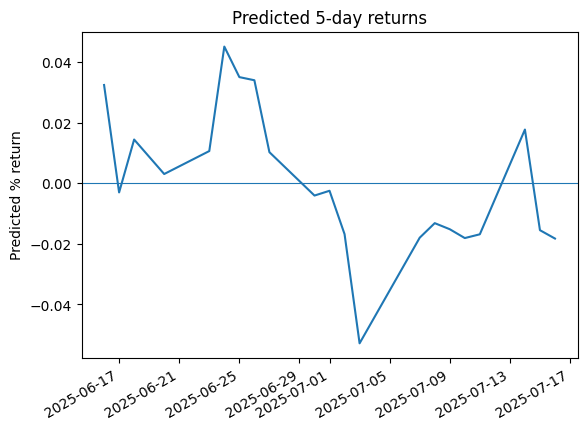

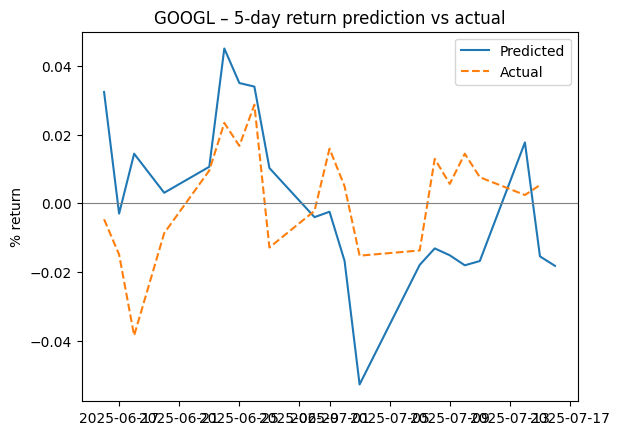

In [22]:
import joblib, collections
import matplotlib.pyplot as plt

def rolling_predict(new_close_price_series):
    buf = collections.deque(maxlen=WINDOW)
    forecasts = {}
    for ts, row in new_close_price_series.iterrows():
        buf.append(row.values)
        if len(buf) == WINDOW:
            emb = ts2vec.encode(np.expand_dims(np.stack(buf), 0), causal=True)[0, -1]
            forecasts[ts] = gbr.predict(emb.reshape(1, -1))[0]
    return pd.Series(forecasts)


# example: last month of unseen data
live_preds = rolling_predict(close.iloc[-(WINDOW+20):])

live_preds.plot(title="Predicted 5-day returns")
plt.axhline(0, lw=0.8)          # zero line for context
plt.ylabel("Predicted % return")
plt.show()

TICKER = "GOOGL"  # or whatever ticker you're predicting
HORIZON = 1

# Realised return
actual = (close[TICKER].shift(-HORIZON) - close[TICKER]) / close[TICKER]

# Align with live_preds
common_idx = live_preds.index.intersection(actual.index)

# Plot
plt.plot(common_idx, live_preds.loc[common_idx], label="Predicted")
plt.plot(common_idx, actual.loc[common_idx], label="Actual", linestyle="--")
plt.axhline(0, lw=0.8, color="gray")
plt.title(f"{TICKER} – 5-day return prediction vs actual")
plt.ylabel("% return")
plt.legend()
plt.show()

Save / Load

In [ ]:
ts2vec.save("ts2vec.pt")
joblib.dump(gbr, "gbr_head.pkl")
# later:
# ts2vec = TS2Vec.load("ts2vec.pt").to(device)
# gbr = joblib.load("gbr_head.pkl")